<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">

</div>
<div style="float: right; width: 50%;">

<p style="margin: 0; text-align:right;">2024-25 · Exploratory Data Analysis</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Grado en Ciencia de Datos y Grado en Física</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# Time series exercise


In [80]:
import pickle

import scipy.stats
from scipy.stats import boxcox
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn import ensemble
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller



%matplotlib inline

For the exercise, we will use the *AirPassangers* dataset, which contains information about the number of flights made over many years.

The first thing we will do is read the data and observe its distribution.

In [81]:
data = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col='Month', header=0)
data = data.rename(columns={'#Passengers': 'Passengers'})
data.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


<Axes: xlabel='Month'>

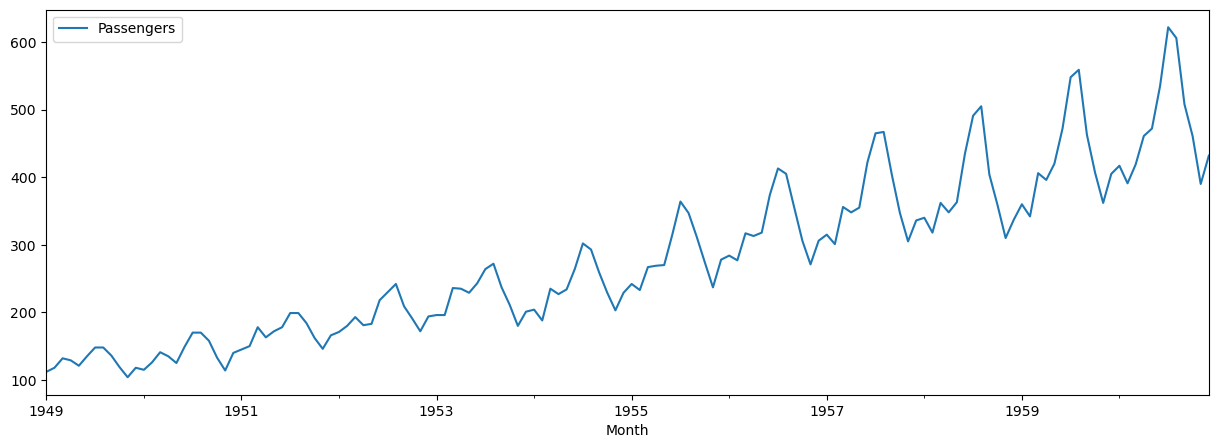

In [82]:
data.plot(figsize=(15, 5))

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementation:</strong>
Describe the aspects you see in the time series and explain the strategy to be used (0.25 points).
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Answer:</strong>This chart represents a time series that depicts the relationship between the number of passengers over time.

First, we can observe a clear overall upward trend in the number of passengers as the months progress, starting at around 100 people in 1949 and reaching approximately 600 between 1960 and 1961. Therefore, we can affirm that both magnitudes, although they do not maintain a perfectly proportional relationship due to the fluctuations present (as it is not a linear representation), show a general direct proportionality, displaying a sustained increase in both over time. On the other hand, due to the observed trend, we can also state that the time series is non-stationary, as its parameters vary over time, along with its mean (the number of passengers increases significantly) and its variance (peaks and valleys become more pronounced). The increase in variance, or simply the fact that it is not constant, indicates that the series exhibits heteroscedasticity. Furthermore, the peaks and valleys themselves suggest a pattern characteristic of seasonality, as part of the fluctuations occur regularly and predictably within a specific time interval. We can observe that the number of passengers tends to increase in certain months, likely summer or holiday months, and decrease in others, possibly winter months, with this pattern repeating annually. Additionally, as previously mentioned, there is a clear variability in the peaks and valleys across different years, such as the evident difference in amplitude between the early and later years. This could signify the presence of other factors affecting the number of passengers, such as periods of economic crisis or changes in the transportation industry. It is also worth noting that no significant outliers or noise deviating drastically from the overall pattern are observed. Since we have defined the time series as non-stationary, heteroscedastic, and exhibiting seasonal patterns, a suitable strategy for modeling and predicting the data would be to decompose the series by identifying, extracting, and representing the trend, seasonality, and residual components, in addition to finding a transformation to address heteroscedasticity. Once this has been studied and obtained, using a model such as SARIMA to fit the predictions and validate them against the original data would be an appropriate approach.

</div>

Before we start dealing with the different components of a time series, we will remove a couple of years of data from the original dataset. This way, when we make a future prediction, we can check if it matches the actual data.





In [83]:
TEST_SIZE = 24
train, test = data.iloc[:-TEST_SIZE], data.iloc[-TEST_SIZE:]
x_train, x_test = np.array(range(train.shape[0])), np.array(range(train.shape[0], data.shape[0]))
train.shape, x_train.shape, test.shape, x_test.shape

train_modif = data.copy()

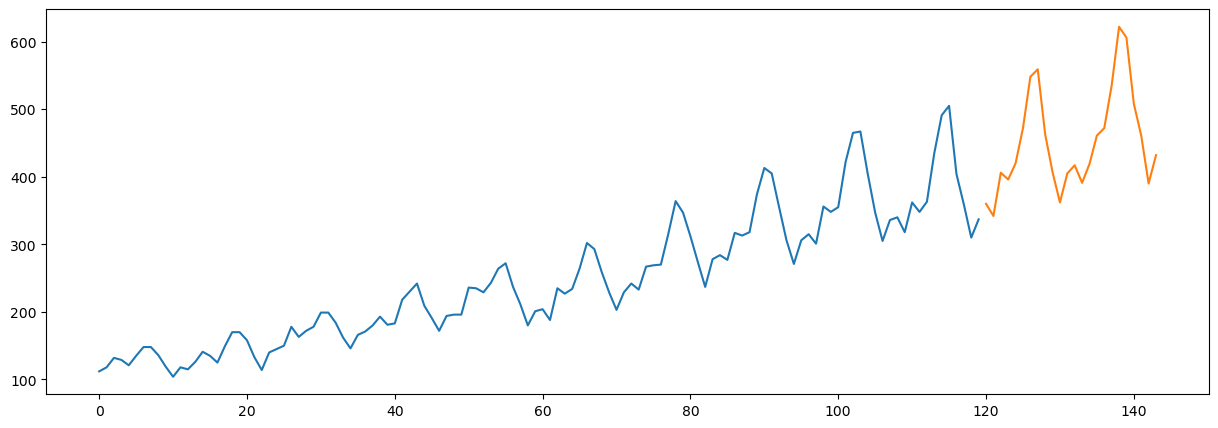

In [84]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(x_train, train)
ax.plot(x_test, test)

##Components of the time series

###  Heterocedasticity

A time series is said to be homoscedastic when its variance remains constant over time. A time series is said to have heteroscedasticity when its variance changes over time.

In the case that the series is homoscedastic, the first thing we will do is eliminate it and convert the series into a homoscedastic one (i.e., ensuring that the difference between the minimum and maximum of the seasonality (annual) remains roughly the same over time), or at least make it as homoscedastic as possible.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementation:</strong>
Eliminate the heteroscedasticity from the series if present. To do this, perform several transformations:

- Comment on which transformation makes the series more homoscedastic and why. (0.5 points)
- Visually demonstrate what was mentioned in the previous section (show the graph). (0.25 points)
- Also, prove it numerically, for example, by calculating the variances of the series. (0.25 points)
- Bonus: Perform a Box-Cox transformation of the series and compare its results with the transformations you have performed. (0.25 points)
</div>

C:\Users\Claudia Torres\AppData\Local\Temp\ipykernel_11780\4013746269.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Log'] = np.log(train['Passengers'])
C:\Users\Claudia Torres\AppData\Local\Temp\ipykernel_11780\4013746269.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Sqrt'] = np.sqrt(train['Passengers'])
C:\Users\Claudia Torres\AppData\Local\Temp\ipykernel_11780\4013746269.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l


Descriptive Statistics:
               Passengers         Log        Sqrt        Diff      BoxCox
count          120.000000  120.000000  120.000000  108.000000  120.000000
mean           245.908333    5.430353   15.395309   28.259259    6.896807
std             94.942087    0.391702    2.994583   16.139214    0.618765
min            104.000000    4.644391   10.198039   -8.000000    5.684721
25%            170.750000    5.140197   13.067124   17.750000    6.433650
50%            233.500000    5.453180   15.280698   28.500000    6.922789
75%            313.500000    5.747796   17.705914   40.250000    7.395167
max            505.000000    6.224558   22.472205   62.000000    8.184885
Range          401.000000    1.580168   12.274166   70.000000    2.500164
Mean - Median   12.408333   -0.022827    0.114611   -0.240741   -0.025983


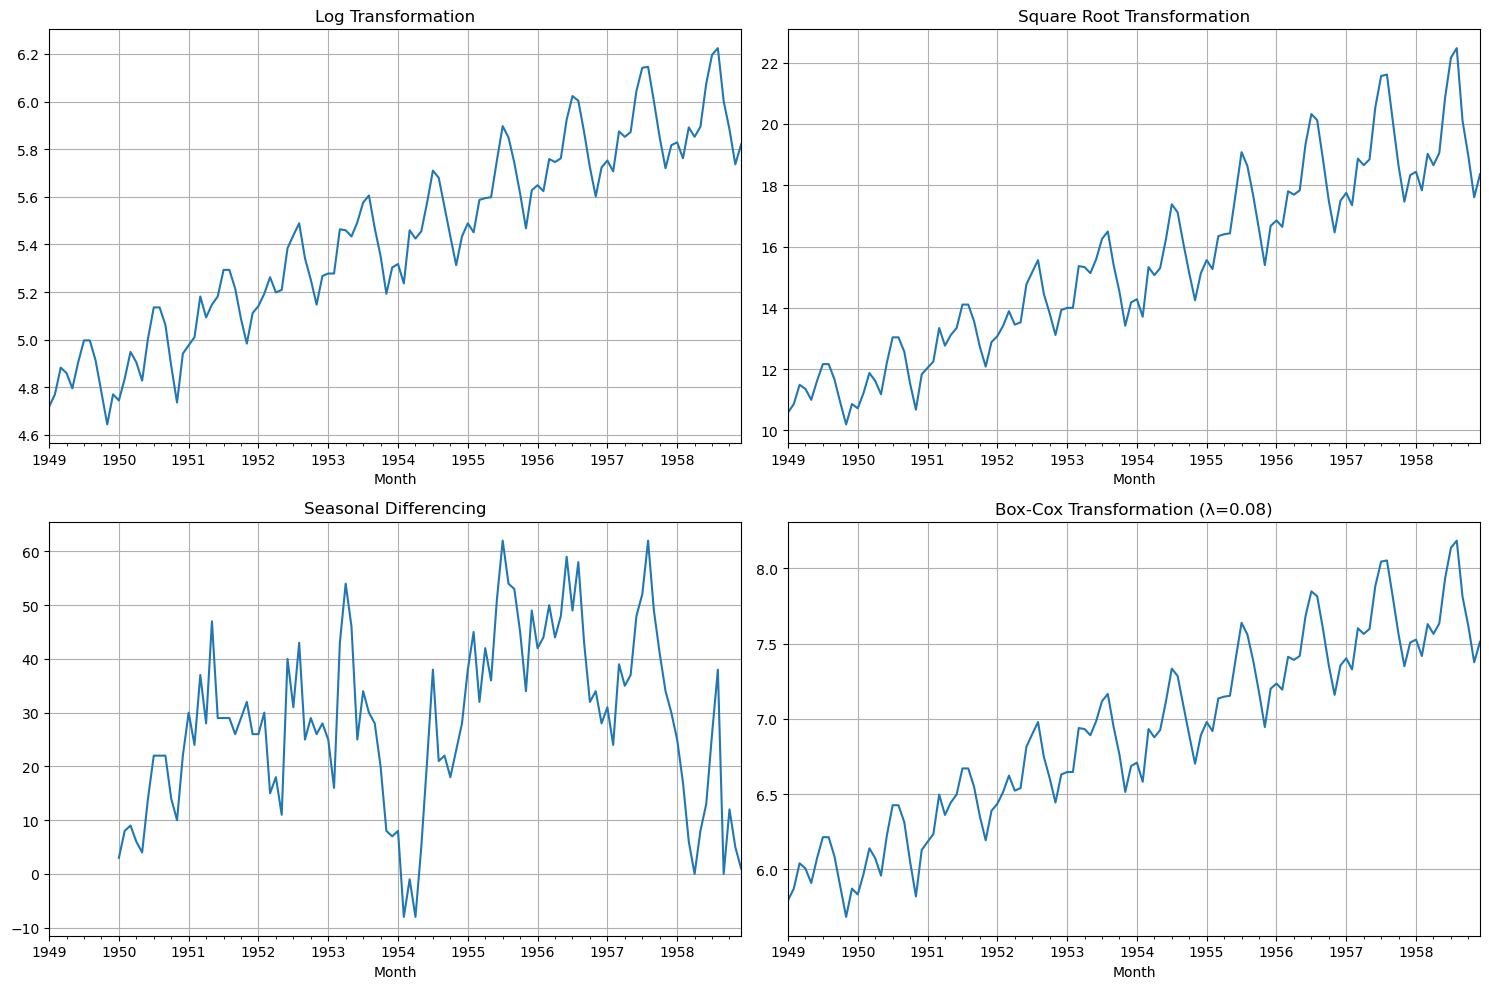


Variance Comparison:
Original: 9014.00
Log Transformation: 0.153430
Square Root Transformation: 8.967528
Seasonal Differencing: 260.47
Box-Cox Transformation: 0.382870


In [85]:


# Log transformation
train['Log'] = np.log(train['Passengers'])

# Square root transformation
train['Sqrt'] = np.sqrt(train['Passengers'])

# Seasonal differencing
train['Diff'] = train['Passengers'].diff(12)

# Box-Cox transformation
train['BoxCox'], lambda_value = boxcox(train['Passengers'].dropna())

# Descriptive statistics
stats = train.describe()

# Add range (max - min) to the statistics
stats.loc['Range'] = stats.loc['max'] - stats.loc['min']

# Add the difference between mean and median
stats.loc['Mean - Median'] = stats.loc['mean'] - stats.loc['50%']

# Display the descriptive statistics
print("\nDescriptive Statistics:")
print(stats)

# Visualization of transformations
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
train['Log'].plot(title='Log Transformation', grid=True)

plt.subplot(2, 2, 2)
train['Sqrt'].plot(title='Square Root Transformation', grid=True)

plt.subplot(2, 2, 3)
train['Diff'].plot(title='Seasonal Differencing', grid=True)

plt.subplot(2, 2, 4)
train['BoxCox'].plot(title=f'Box-Cox Transformation (λ={lambda_value:.2f})', grid=True)

plt.tight_layout()
plt.show()

# Variance comparison
var_original = train['Passengers'].var()
var_log = train['Log'].var()
var_sqrt = train['Sqrt'].var()
var_diff = train['Diff'].var()
var_boxcox = train['BoxCox'].var()

print("\nVariance Comparison:")
print(f"Original: {var_original:.2f}")
print(f"Log Transformation: {var_log:.6f}")
print(f"Square Root Transformation: {var_sqrt:.6f}")
print(f"Seasonal Differencing: {var_diff:.2f}")
print(f"Box-Cox Transformation: {var_boxcox:.6f}")

### **Comment on Which Transformation Makes the Series More Homoscedastic and Why**

To study heteroscedasticity, we will use three of the most common transformations: logarithmic, square root, and differencing, analyzing their impact on the variance and other statistical properties.

---

### **Logarithmic Transformation**

This transformation is typically used when the variance increases proportionally with the level of the series. It compresses large values more than small ones, which can help stabilize the variance. Here's an example of the logarithmic effect on the data at the beginning and end of the series:

- 1949-1951: 120 passengers → ln(120) ≈ 4.787, 150 → ln(150) ≈ 5.011
- 1959-1961: 580 passengers → ln(580) ≈ 6.363, 600 → ln(600) ≈ 6.397

This helps reduce the relative differences between values, especially between high and low ones:

- In the original series: 580 - 120 = 460
- With logarithms: 6.363 - 4.787 = 1.576

This results in a compression of the data, making the variance more constant or stable over time. This is particularly useful because our series exhibits multiplicative seasonality due to its exponential growth.

---

### **Square Root Transformation**

The square root is a milder transformation than the logarithm and is useful when the variance grows with the level but not as aggressively as in a multiplicative case.  
Example:

- 1949-1951: 120 passengers → √(120) ≈ 10.954
- 1959-1961: 580 passengers → √(580) ≈ 24.083
- 24.083 - 10.954 = 13.129

This results in less compression than the logarithmic transformation and, therefore, does not stabilize the variance as effectively, especially in cases of heteroscedasticity strongly related to exponential trends.

---

### **Differencing Transformation**

Differencing involves subtracting each value from the previous one. This eliminates trends and can stabilize the variance if heteroscedasticity is due to a linear trend. However, it may not directly address seasonality.

---

### **Conclusion**

Based on the above, we can conclude that the **logarithmic transformation** provides the most stability in variance, making it the most effective at reducing heteroscedasticity and bringing the series closer to homoscedasticity. To reinforce this conclusion, we will use graphical representations of each transformation for visualization.

---

### **Graphs**

Among the three transformations mentioned, we can reaffirm that the logarithmic transformation exhibits the most homoscedasticity, as it shows the peaks and valleys with the least difference in amplitude over time. The second-best transformation is the square root, as the amplitudes are relatively similar but with a visible difference between the beginning and the end.

---

### **Prove It Numerically**

To further support this conclusion, we will now analyze descriptive statistical data.

We can follow these criteria to determine which transformation is the most effective:
- **Difference between mean and median closest to 0**: Indicates symmetry in the distribution (highly skewed data often have heterogeneous variance because extreme values inflate dispersion in certain regions).
- **Lower standard deviation (std)**: Indicates lower variability and greater stabilization of variance.
- **Narrow range (max - min)**: Can improve symmetry and increase variance stability.

We will primarily rely on the standard deviation results, as it is the most reliable and direct measure of data dispersion and, therefore, provides a clear idea of variance. Symmetry and narrow range will be used as supporting criteria.

As shown in the table with the statistical data, the logarithmic transformation best meets the criteria, making it the most effective transformation.

Additionally, when directly calculating the variances for each transformation, the logarithmic transformation also yields the lowest variance.

Therefore, compared to the square root and differencing transformations, the logarithmic transformation brings the series closest to homoscedasticity.

---

### **Box-Cox Transformation**

Now considering the Box-Cox transformation, we can see in the graphical representation that it has a very similar shape to the logarithmic transformation, indicating similar variance stability. To compare homoscedasticity and determine which provides greater stability, we refer to the table of statistical data and variance comparisons. In the first case, we observe that after the logarithmic transformation, the Box-Cox transformation is the second-best fit to the mentioned criteria. Similarly, in terms of variances, it also has the second-lowest result, making it the second-best transformation overall.

### Tendency

The trend is the long-term behavior of the data.  

In our time series, we have a growing linear trend. In this section, you need to remove the trend, leaving a time series with a constant trend.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementation:</strong>

Identify if there is a trend in the time series and what type it is.
Remove the trend from the data: If there is a trend, apply a method to remove it (0.5 points)
Plot the data without the trend. (0.5 points) 
</div>

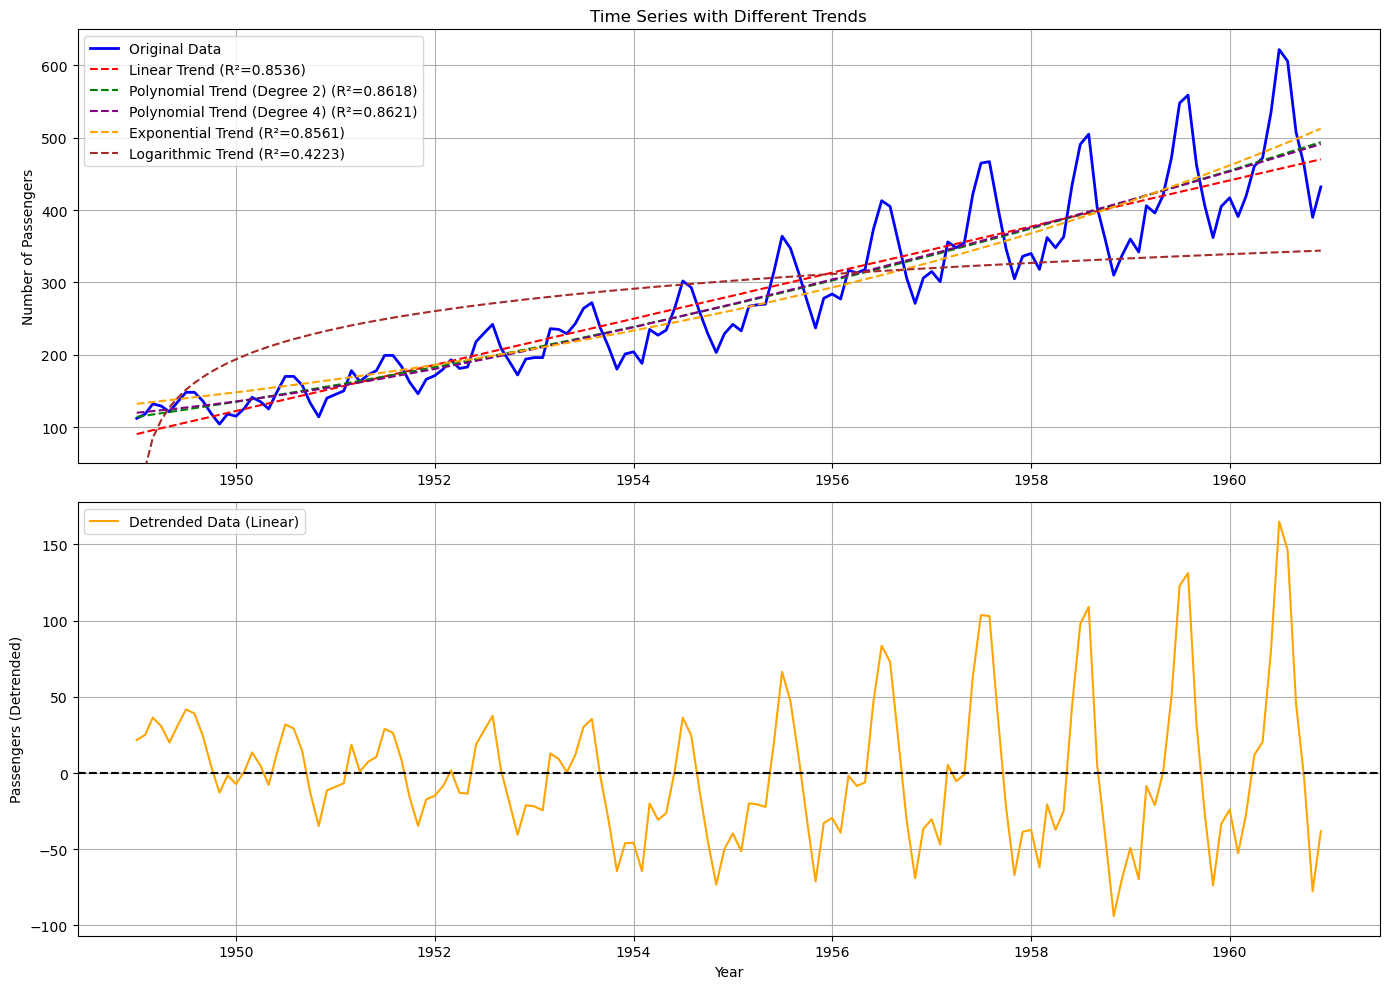

In [86]:
from scipy.optimize import curve_fit

# Load the data
data = pd.read_csv('AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

# Create a normalized time variable
data.rename(columns={'#Passengers': 'Passengers'}, inplace=True)
data['Time'] = np.arange(len(data)) / len(data)

# Exponential fitting function
def exp_func(x, a, b):
    return a * np.exp(b * x)

# Logarithmic fitting function
def log_func(x, a, b):
    return a + b * np.log(x + 1e-5)

# R^2 calculation function
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

# Linear trend fitting
coef_linear = np.polyfit(data['Time'], data['Passengers'], 1)
trend_linear = np.polyval(coef_linear, data['Time'])
r2_linear = r2_score(data['Passengers'], trend_linear)

# Polynomial trend fitting (degree 2)
coef_poly2 = np.polyfit(data['Time'], data['Passengers'], 2)
trend_poly2 = np.polyval(coef_poly2, data['Time'])
r2_poly2 = r2_score(data['Passengers'], trend_poly2)

# Polynomial trend fitting (degree 4)
coef_poly4 = np.polyfit(data['Time'], data['Passengers'], 4)
trend_poly4 = np.polyval(coef_poly4, data['Time'])
r2_poly4 = r2_score(data['Passengers'], trend_poly4)

# Exponential trend fitting
try:
    popt_exp, _ = curve_fit(exp_func, data['Time'], data['Passengers'], maxfev=10000)
    trend_exp = exp_func(data['Time'], *popt_exp)
    r2_exp = r2_score(data['Passengers'], trend_exp)
except RuntimeError:
    trend_exp = np.nan * np.ones_like(data['Passengers'])
    r2_exp = np.nan

# Logarithmic trend fitting
try:
    popt_log, _ = curve_fit(log_func, data['Time'], data['Passengers'], maxfev=10000)
    trend_log = log_func(data['Time'], *popt_log)
    r2_log = r2_score(data['Passengers'], trend_log)
except RuntimeError:
    trend_log = np.nan * np.ones_like(data['Passengers'])
    r2_log = np.nan

# Remove the trend using the linear trend
data['Detrended'] = data['Passengers'] - trend_linear

# Save the detrended data in train_modif
#train_modif = data.copy()

# Create a figure with two subplots
plt.figure(figsize=(14, 10))

# Upper plot: Original data with trends overlaid
plt.subplot(2, 1, 1)
plt.plot(data['Passengers'], label='Original Data', color='blue', linewidth=2)
plt.plot(data.index, trend_linear, label=f'Linear Trend (R²={r2_linear:.4f})', color='red', linestyle='--')
plt.plot(data.index, trend_poly2, label=f'Polynomial Trend (Degree 2) (R²={r2_poly2:.4f})', color='green', linestyle='--')
plt.plot(data.index, trend_poly4, label=f'Polynomial Trend (Degree 4) (R²={r2_poly4:.4f})', color='purple', linestyle='--')
if not np.isnan(r2_exp):
    plt.plot(data.index, trend_exp, label=f'Exponential Trend (R²={r2_exp:.4f})', color='orange', linestyle='--')
if not np.isnan(r2_log):
    plt.plot(data.index, trend_log, label=f'Logarithmic Trend (R²={r2_log:.4f})', color='brown', linestyle='--')

plt.title('Time Series with Different Trends')
plt.ylim(50, 650)
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)

# Lower plot: Detrended data
plt.subplot(2, 1, 2)
plt.plot(data['Detrended'], label='Detrended Data (Linear)', color='orange')
plt.xlabel('Year')
plt.ylabel('Passengers (Detrended)')
plt.axhline(y=0, color='black', linestyle='--')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

To study the trend, we use the original data without transformation, as we are interested in their original properties. The first graph shows different types of superimposed trends: linear, polynomial, exponential, and logarithmic.
The coefficient of determination (R^2) indicates how well the model fits the data: values close to 1 represent a good fit, while values close to 0 indicate a poor fit.
We conclude that the trend of our time series is polynomial of degree 4, as it best fits the data with an 
R^2=0.8621


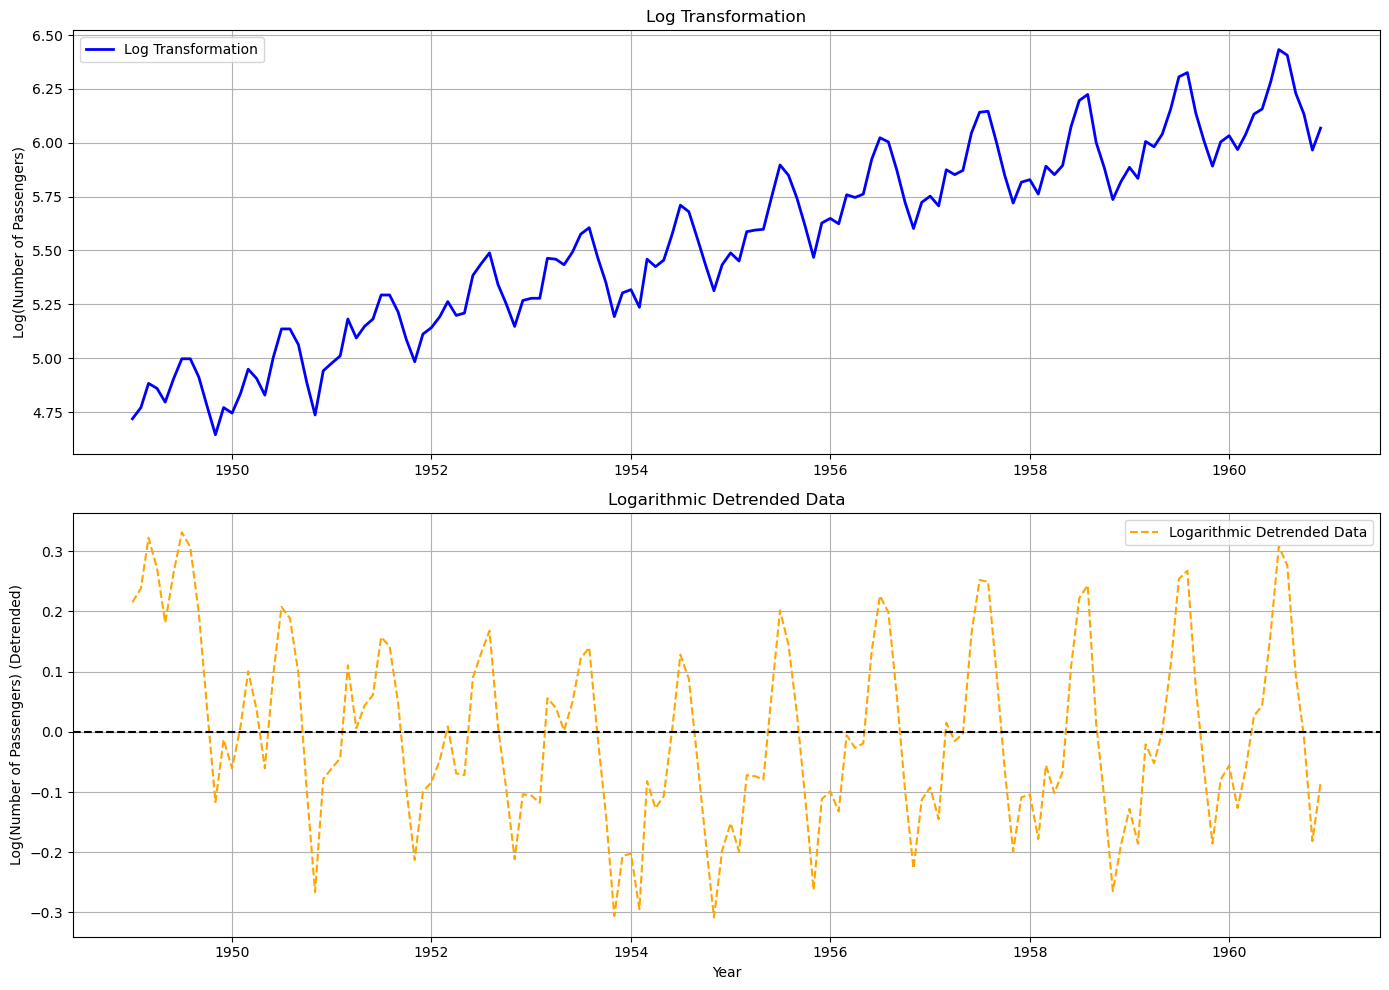

In [87]:
# Apply the logarithmic transformation to train_modif
train_modif['Log'] = np.log(train_modif['Passengers'])

# Remove the trend from the logarithmic transformation
train_modif['Log_Detrended'] = train_modif['Log'] - np.log(trend_linear[:len(train_modif)])

# Plot to verify the transformations
plt.figure(figsize=(14, 10))

# Upper plot: Logarithmic transformation
plt.subplot(2, 1, 1)
plt.plot(train_modif['Log'], label='Log Transformation', color='blue', linewidth=2)
plt.title('Log Transformation')
plt.ylabel('Log(Number of Passengers)')
plt.legend()
plt.grid(True)

# Lower plot: Logarithmic detrended data
plt.subplot(2, 1, 2)
plt.plot(train_modif['Log_Detrended'], label='Logarithmic Detrended Data', color='orange', linestyle='--')
plt.title('Logarithmic Detrended Data')
plt.xlabel('Year')
plt.ylabel('Log(Number of Passengers) (Detrended)')
plt.axhline(y=0, color='black', linestyle='--')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

We can observe how the code successfully detrended the logarithmic transformation of the data of train_modif DataFrame.

### Seasonality

We define seasonality as the cyclical variation that occurs in the data. In this section, seasonality should be identified and removed.

####  **Find the period of seasonality (0.5 points)**

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementation:</strong> First, you need to find the cycle, that is, how often the data repeats. To find it, you can use autocorrelation (i.e., *numpy* allows you to obtain the correlation coefficients).

The idea is to compare:

- The original series with the series starting from the second point (i.e., series[1:])
- The original series with the series starting from the third point (i.e., series[2:])
- ...

When the cycle starts over, the series will be very similar to the original series, and therefore, the correlation will be very high. The point where the correlation is maximum will be the cycle of the series.

Graphically show the coefficients of the first 26 autocorrelation values and determine the maximum value; this will be our seasonality.

    
<u>NOTA</u>: Si usais <i>numpy</i> para encontrar los coeficientes de correlación, las dos series que comparéis deben de tener la misma longitud. Para representar la serie original podéis eliminar los valores del final para que tenga la misma longitud que la serie "movida". Por ejemplo, en el primer caso podéis comparar serie[1:] con serie[:-1].
</div>

To facilitate the identification and modeling of seasonality, we should study the series by applying the logarithmic transformation and removing the identified trend.

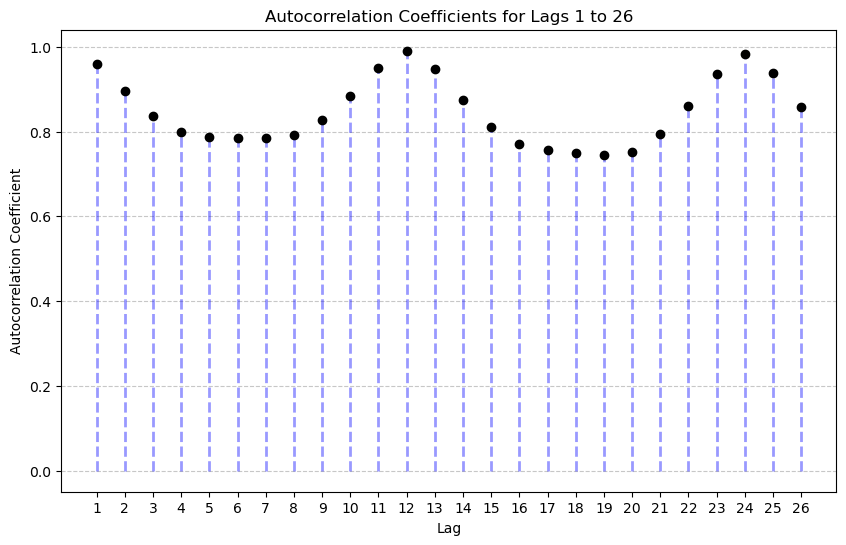

The maximum autocorrelation occurs at lag 12, indicating a seasonality of 12 months.


In [88]:
# Calculate autocorrelation coefficients
autocorrelations = []
passengers = train_modif['Passengers'].values

for lag in range(1, 27):  # Calculate for the first 26 lags
    correlation = np.corrcoef(passengers[:-lag], passengers[lag:])[0, 1]
    autocorrelations.append(correlation)

# Plot the autocorrelation coefficients with vertical lines ending in points
plt.figure(figsize=(10, 6))
for lag, autocorr in enumerate(autocorrelations, start=1):
    plt.plot([lag, lag], [0, autocorr], color='blue', linewidth=2, linestyle='--', alpha=0.4)  # Vertical line
    plt.plot(lag, autocorr, 'o', color='black')  # Point at the end of the line

plt.title('Autocorrelation Coefficients for Lags 1 to 26')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation Coefficient')
plt.xticks(range(1, 27))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Determine the lag with the maximum autocorrelation
max_lag = np.argmax(autocorrelations) + 1
print(f"The maximum autocorrelation occurs at lag {max_lag}, indicating a seasonality of {max_lag} months.")

The graph shows the autocorrelation of the first 26 lags in the training data, and in it we can observe clear peaks at certain lags, especially around lags 12 and 24, indicating strong seasonality at these points.

####  Apply a SARIMA model

To address seasonality, we will apply a SARIMA model. The acronym stands for "Seasonal ARIMA," meaning an ARIMA model with seasonality (the one we just found).

The ARIMA model allows us to handle the noise left after removing heteroscedasticity, trend, and seasonality. It takes into account the following components:

- **AR**: Auto-regressive, denoted as *p*. It considers the correlation with its lags, meaning it looks at whether past observations influence the calculation of the next point.
- **I**: Integrated, denoted as *d*. This is the order of differencing, which, in our case, is not necessary since the series no longer has heteroscedasticity or trend.
- **MA**: Moving-average, denoted as *q*. It considers the correlation with the lags of the errors, meaning once the model is applied, it looks at the model errors versus the real data.

For more information on ARIMA, you can consult this link: https://otexts.com/fpp2/arima.html

SARIMA models depend on several parameters: (p,d,q)(P,D,Q)s, where the first set (lowercase) corresponds to AR, I, and MA of the normal series, and the second set (uppercase) corresponds to AR, I, and MA with seasonality.

To find these parameters, we need to look at the PACF (<i>partial autocorrelation function<i>) and ACF (<i>autocorrelation function<i>) plots.

The PACF plot determines the *p* parameter, i.e., the AR.


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementation:</strong>Apply a SARIMA model to the data without heteroscedasticity or trend. You can use SARIMAX (from <i>statsmodels.tsa.statespace.sarimax<i>) with the parameters you find.

- Create the ACF and PACF plots and determine the possible values for *p*, *P*, *Q*, *q* (1 point)
- Perform the ADF test. Comment on the results (0.75 points)
- Apply the SARIMAX model (0.5 points)
- Graphically show the model results along with the original series to compare if it fits well. Comment on the result (1.5 points)

Graphically show the model results along with the original series to compare if it fits well.
</div>

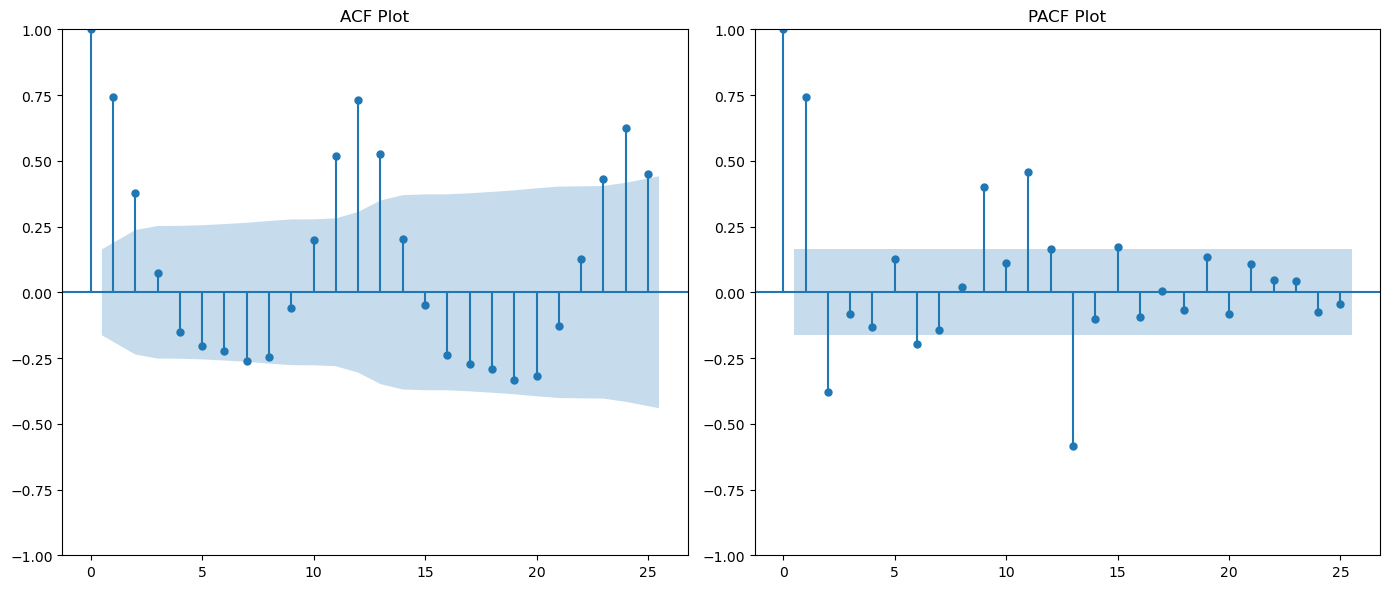

In [89]:
# Step 1: ACF and PACF plots

plt.figure(figsize=(14, 6))

# ACF plot
plt.subplot(1, 2, 1)
plot_acf(train_modif['Log_Detrended'].dropna(), lags=25, ax=plt.gca())
plt.title('ACF Plot')

# PACF plot
plt.subplot(1, 2, 2)
plot_pacf(train_modif['Log_Detrended'].dropna(), lags=25, ax=plt.gca(), method='ywm')
plt.title('PACF Plot')

plt.tight_layout()
plt.show()


Plot ACF Analysis

    - The ACF does not cut off abruptly but decays gradually, suggesting that there is no pure MA component ((q=0)).
    - No clear seasonal patterns are observed. This suggests that (Q) could be 0, as there is no evident seasonal MA component.

Plot PACF Analysis

    - The PACF has significant spikes at lags 1 and 2, and then it drops to 0. This suggests that (p=2), as the AR component seems to include up to lag 2.
    - No clear seasonal patterns are observed (such as significant spikes at multiples of (s)). This suggests that (P) could be 0, as there is no evident seasonal AR component.

Therefore:
q = 0, Q = 0, p = 2, P = 0, d=0, D=0 (no seasonal differencing ), s=12 (monthly seasonality )

In [90]:
# Step 2: Perform the ADF test

adf_test = adfuller(train_modif['Log_Detrended'].dropna())
print("ADF Test Results:")
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")
print(f"Critical Values: {adf_test[4]}")

if adf_test[1] < 0.05:
    print("The series is stationary (reject the null hypothesis).")
else:
    print("The series is not stationary (fail to reject the null hypothesis).")

ADF Test Results:
ADF Statistic: -2.3617759048808944
p-value: 0.1528166968787451
Critical Values: {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
The series is not stationary (fail to reject the null hypothesis).


The result indicates that the series is not stationary, as the test statistic is -2.235, which is greater than all the critical values (-3.4936, -2.8892, and -2.5815). Therefore, there is not enough evidence to reject the null hypothesis, and we cannot conclude that the series is stationary. Additionally, this conclusion is reaffirmed by the p-value result, which is 0.1938. This value is greater than 0.05, meaning that the series has a unit root, implying non-stationarity.

There are several reasons why the series remains non-stationary:

Due to the presence of seasonality, that is, it exhibits annual cycles, which can maintain non-stationarity even after removing the trend.
Strong correlations between lagged values.
The remaining fluctuations (residuals) that still persist in the series after removing the trend might still exhibit non-stationary behavior.
To make the series stationary, we need to address seasonality and any remaining autocorrelation by applying differencing before applying the SARIMA model. We apply the seasonal difference due to the demonstrated seasonal patterns present in the series.

c:\Users\Claudia Torres\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Claudia Torres\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


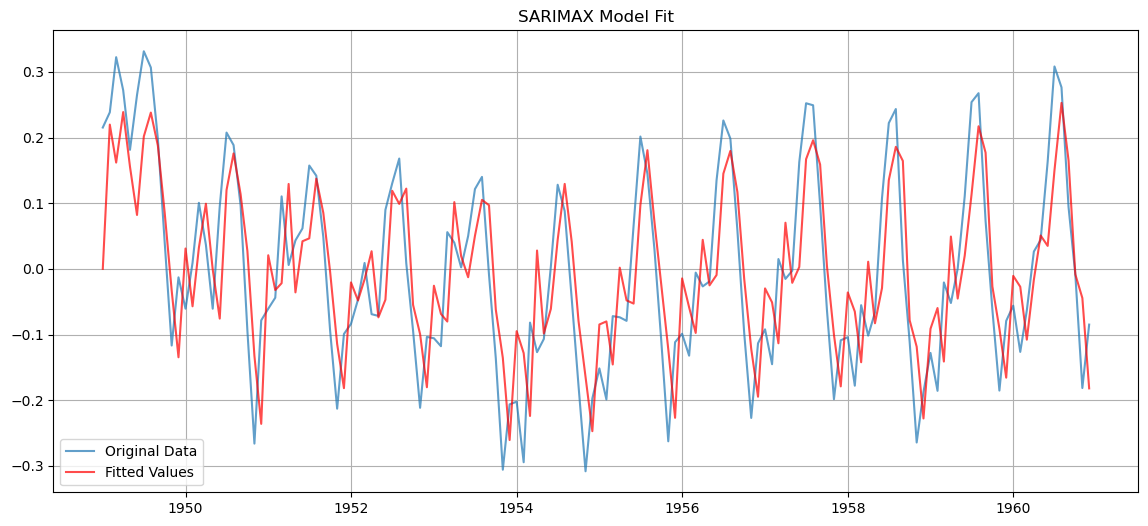

Model Summary:
                               SARIMAX Results                                
Dep. Variable:          Log_Detrended   No. Observations:                  144
Model:               SARIMAX(2, 0, 0)   Log Likelihood                 137.877
Date:                Tue, 01 Apr 2025   AIC                           -269.753
Time:                        14:17:43   BIC                           -260.886
Sample:                    01-01-1949   HQIC                          -266.150
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0207      0.077     13.325      0.000       0.871       1.171
ar.L2         -0.3785      0.079     -4.807      0.000      -0.533      -0.224
sigma2         0.0084      0.002     

In [129]:

# Step 3: Apply the SARIMAX model
# Based on ACF and PACF, we choose p=2, d=0 , q=0, P=0, D=0, Q=0, s=12
sarimax_model = SARIMAX(train_modif['Log_Detrended'].dropna(),
                        order=(2, 0, 0),
                        seasonal_order=(0, 0, 0, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
results = sarimax_model.fit(disp=False)

# Step 4: Plot the model results
plt.figure(figsize=(14, 6))
plt.plot(train_modif['Log_Detrended'], label='Original Data', alpha=0.7)
plt.plot(results.fittedvalues, label='Fitted Values', color='red', alpha=0.7)
plt.title('SARIMAX Model Fit')
plt.legend()
plt.grid(True)
plt.show()

# Comment on the results
print("Model Summary:")
print(results.summary())


The red line (fitted values) and the blue line (original data) are very close, capturing the general shape and trend well, but there is a noticeable separation between them with some differences/deviations. This indicates that the model has minimally captured the general patterns of the data in terms of seasonality and fluctuations (in general, the shape of the valleys and peaks is very similar), but not completely  

In [ ]:
We try to get it stationary. 

In [ ]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Step 1: Apply seasonal differencing (lag 12 for monthly data)
train_modif['Log_Detrended_Seasonal'] = train_modif['Log_Detrended'].diff(12)

# Step 2: Apply first differencing to remove residual non-stationarity
train_modif['Log_Detrended_Stationary'] = train_modif['Log_Detrended_Seasonal'].diff()

# Step 3: Drop NaN values (caused by differencing)
stationary_series = train_modif['Log_Detrended_Stationary'].dropna()

# Step 4: Perform the ADF test on the stationary series
adf_test = adfuller(stationary_series)
print("ADF Test Results After Differencing:")
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")
print(f"Critical Values: {adf_test[4]}")

if adf_test[1] < 0.05:
    print("The series is stationary (reject the null hypothesis).")
else:
    print("The series is not stationary (fail to reject the null hypothesis).")

ADF Test Results After Differencing:
ADF Statistic: -4.378651154285672
p-value: 0.0003237484998142903
Critical Values: {'1%': -3.4870216863700767, '5%': -2.8863625166643136, '10%': -2.580009026141913}
The series is stationary (reject the null hypothesis).


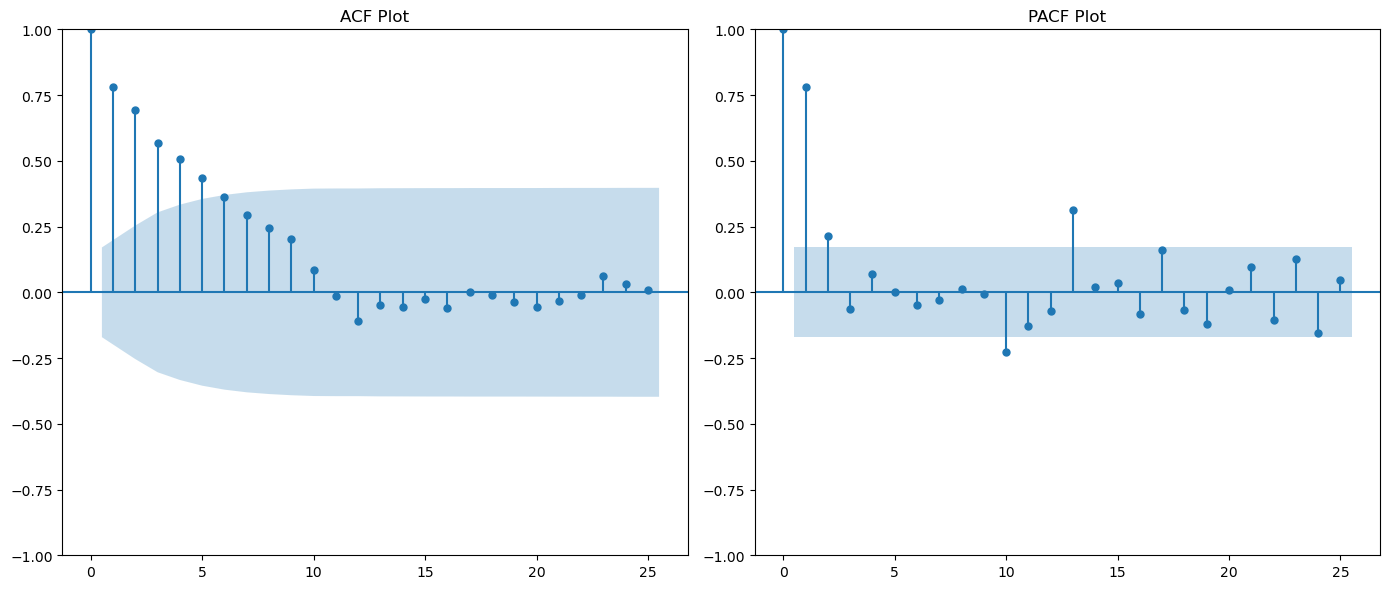

In [96]:
plt.figure(figsize=(14, 6))

# ACF plot
plt.subplot(1, 2, 1)
plot_acf(train_modif['Log_Detrended_Seasonal'].dropna(), lags=25, ax=plt.gca())
plt.title('ACF Plot')

# PACF plot
plt.subplot(1, 2, 2)
plot_pacf(train_modif['Log_Detrended_Seasonal'].dropna(), lags=25, ax=plt.gca(), method='ywm')
plt.title('PACF Plot')

plt.tight_layout()
plt.show()

Following past reasoning, we finally get:

p=1, q=2, P=0, Q=1, s=12, d=2 (differencing applied ), D=1 ( seasonal differencing)


c:\Users\Claudia Torres\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Claudia Torres\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


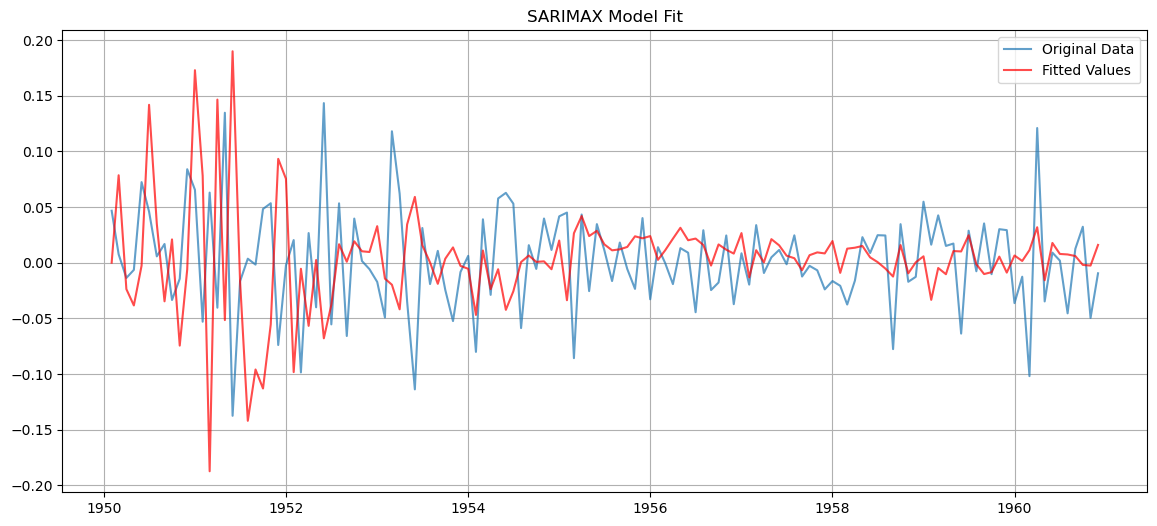

Model Summary:
                                      SARIMAX Results                                       
Dep. Variable:             Log_Detrended_Stationary   No. Observations:                  131
Model:             SARIMAX(1, 2, 2)x(0, 1, [1], 12)   Log Likelihood                 172.618
Date:                              Tue, 01 Apr 2025   AIC                           -335.236
Time:                                      14:19:15   BIC                           -322.111
Sample:                                  02-01-1950   HQIC                          -329.921
                                       - 12-01-1960                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2689      0.082     -3.292      0.001      -0.429      -0.109
ma.L

In [131]:

# Step 3: Apply the SARIMAX model
# Based on ACF and PACF, we choose p=1, d=2, q=2, P=0, D=1, Q=1, s=12
sarimax_model = SARIMAX(train_modif['Log_Detrended_Stationary'].dropna(),
                        order=(1, 2, 2),
                        seasonal_order=(0, 1, 1, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
results = sarimax_model.fit(disp=False)

# Step 4: Plot the model results
plt.figure(figsize=(14, 6))
plt.plot(train_modif['Log_Detrended_Stationary'], label='Original Data', alpha=0.7)
plt.plot(results.fittedvalues, label='Fitted Values', color='red', alpha=0.7)
plt.title('SARIMAX Model Fit')
plt.legend()
plt.grid(True)
plt.show()

# Comment on the results
print("Model Summary:")
print(results.summary())

We will discard this option and continuing working with 'Log_Detendred' and not 'Log_Detendred_Stationary' data.

## Forecast

Let's predict the next two years and compare the prediction with the actual data. We will follow the following steps:

   - Generate a prediction using SARIMA
   - Add the tendency previosuly observed
   - Add heterocedasticity

### SARIMA Forecast

We will use the SARIMA model we adjusted earlier to predict the next two years.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementation:</strong> Generate two years of data using the SARIMA model fitted in the previous section. Plot the entire series (without heteroscedasticity or trend), differentiating the actual series from the two years of prediction using different colors. </div>

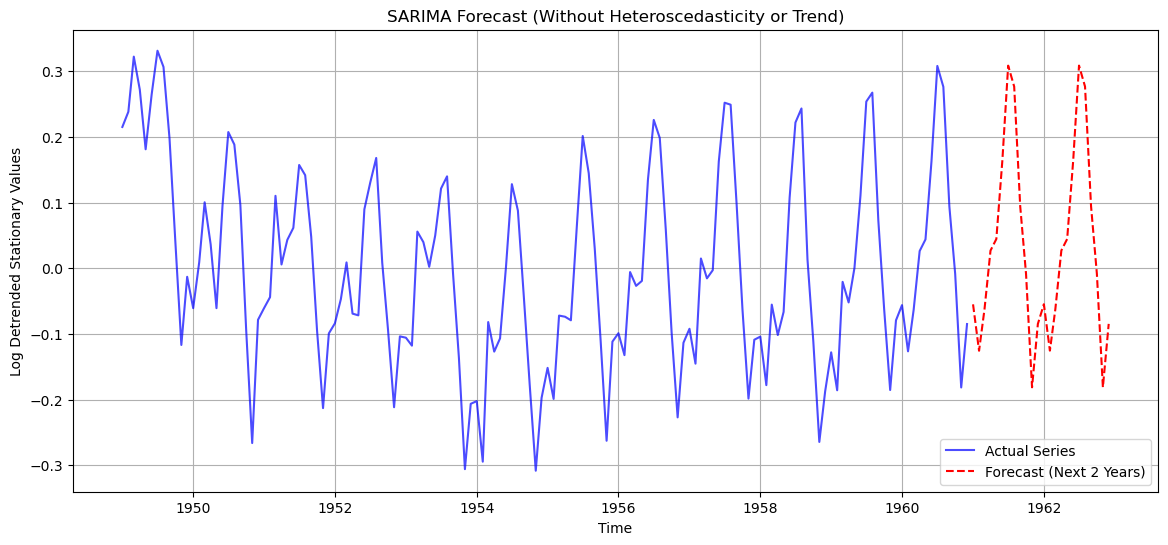

In [116]:
# Generate predictions for the next two years
forecast_steps = TEST_SIZE  # Two years of monthly data
forecast = results.get_forecast(steps=forecast_steps)
forecast_values = forecast.predicted_mean

# Plot the actual series and the forecast
plt.figure(figsize=(14, 6))
plt.plot(train_modif['Log_Detrended'], label='Actual Series', color='blue', alpha=0.7)
plt.plot(forecast_values.index, forecast_values, label='Forecast (Next 2 Years)', color='red', linestyle='--')
plt.title('SARIMA Forecast (Without Heteroscedasticity or Trend)')
plt.xlabel('Time')
plt.ylabel('Log Detrended Stationary Values')
plt.legend()
plt.grid(True)
plt.show()

### Tendency

Previously, we saw that the time series data had a trend, and we removed it. Now we will need to add it back.



<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementation:</strong>

- Add the trend to the prediction (0.5 points).
- Graph the entire series (without heteroscedasticity but with trend), differentiating the actual series from the two years of prediction using different colors. (0.5 points)
</div>

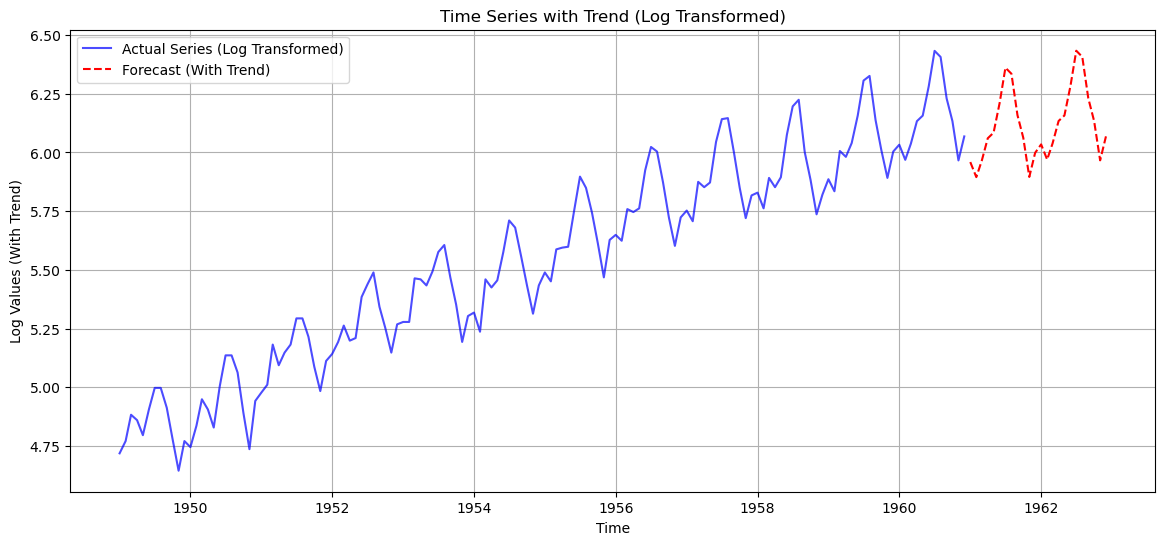

In [118]:
# Add the trend back to the forecast
forecast_with_trend = forecast_values + np.log(trend_linear[-TEST_SIZE:])

# Combine the original series and the forecast
full_series_with_trend = pd.concat([train_modif['Log'], forecast_with_trend])

# Plot the entire series
plt.figure(figsize=(14, 6))
plt.plot(train_modif['Log'], label='Actual Series (Log Transformed)', color='blue', alpha=0.7)
plt.plot(forecast_with_trend.index, forecast_with_trend, label='Forecast (With Trend)', color='red', linestyle='--')
plt.title('Time Series with Trend (Log Transformed)')
plt.xlabel('Time')
plt.ylabel('Log Values (With Trend)')
plt.legend()
plt.grid(True)
plt.show()

### Heterocedasticity

In the first section of the exercise, we saw that the time series had heteroscedasticity, and we removed it by transforming the data. In this section, we will perform the inverse transformation to add heteroscedasticity to our prediction.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementation:</strong>

- Add heteroscedasticity to the previous series by applying the inverse function found in the first section (0.5 points).
    
- Graph the entire series, differentiating the actual series from the two years of prediction with different colors. (0.5 points)
</div>

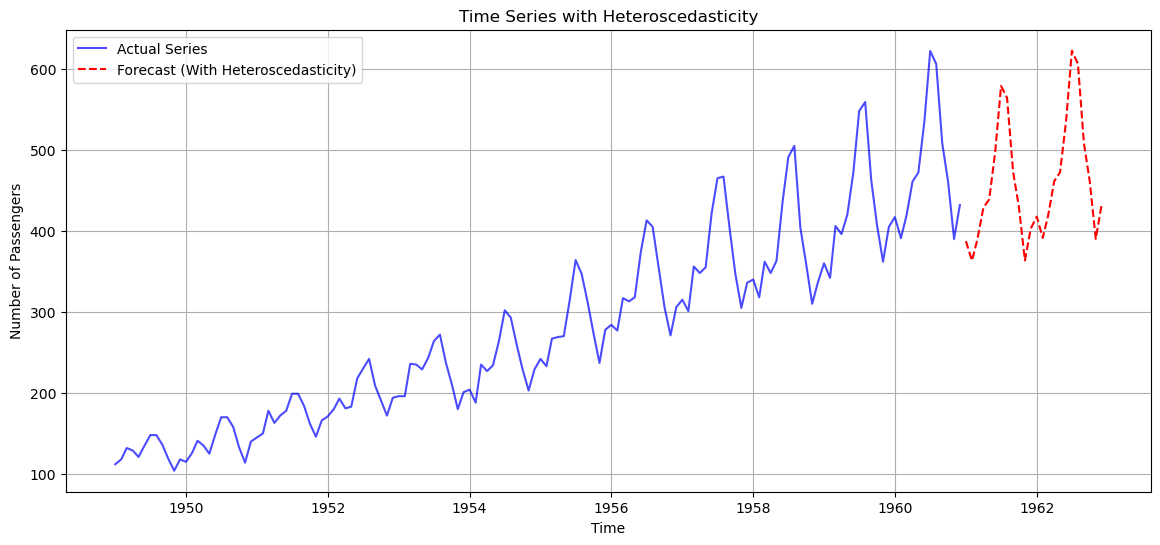

In [119]:
# Add heteroscedasticity by applying the inverse of the logarithmic transformation
forecast_with_heteroscedasticity = np.exp(forecast_with_trend)

# Combine the original series and the forecast with heteroscedasticity
full_series_with_heteroscedasticity = pd.concat([train_modif['Passengers'], forecast_with_heteroscedasticity])

# Plot the entire series
plt.figure(figsize=(14, 6))
plt.plot(train_modif['Passengers'], label='Actual Series', color='blue', alpha=0.7)
plt.plot(forecast_with_heteroscedasticity.index, forecast_with_heteroscedasticity, label='Forecast (With Heteroscedasticity)', color='red', linestyle='--')
plt.title('Time Series with Heteroscedasticity')
plt.xlabel('Time')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementation:</strong>
Comment on all the results obtained during the exercise and reason whether the results are good or bad, explaining why. In case they are not entirely optimal, discuss what you could have done to improve them (1.25 points).
</div>

We can conclude that in both graphs, the models manage to capture the general upward trend and grasp the general idea or pattern of seasonality and heteroscedasticity. However, they fail to capture the exact magnitude of the seasonal fluctuations and variability, indicating that they are not optimal as they do not accurately model the peaks, valleys, and the increase in variance.